# Rain Episodes
## FloodNet NYC Tutorial
Author: Mark Bauer

# Summary

In [05-temporal-patterns.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/05-temporal-patterns.ipynb) we grouped flood events into **rain episodes**: stretches of time when flooding is happening somewhere in the non-tidal network. Two events belong to the same episode if the second starts within 6 hours of the end of the flooding before it.

That rule is a judgment call, and every count in that notebook rests on it. This notebook is the check we owe it. We ask whether the rule does what we think on a storm we can read event by event, whether the implementation details are right, and whether the conclusions survive a different choice of threshold. Then we look at what the grouping actually produced.

1. **Setup**
   - Rebuilding the episodes from [05-temporal-patterns.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/05-temporal-patterns.ipynb)

---

2. **A Worked Example: August 7-9, 2026**
   - The rule step by step
   - The same window as a picture

---

3. **Why `cum_max` and Not the Previous Row**

---

4. **How Much Does the 6-Hour Choice Matter?**
   - The distribution of gaps
   - Rebuilding the biggest storms at other thresholds

---

5. **What the Grouping Produced**

---

6. **Every Episode in the Record**

---

7. **Episodes Versus Calendar Days**

# Import Libraries

In [1]:
# libraries
# Standard library
from pathlib import Path

# Third-party
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import floodnet

# series colors
colors = floodnet.COLORBLIND_PALETTE
NON_TIDAL_COLOR = colors[0]  # blue

# 1) Setup
This section rebuilds the rain episodes exactly as [05-temporal-patterns.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/05-temporal-patterns.ipynb) does, without re-deriving the reasoning behind each step. For why we treat the timestamps as UTC, why tidal sensors are set aside, and where the 4-inch depth threshold comes from, see that notebook.

In [2]:
# read the two datasets and join them on sensor_id
metadata_df = pl.read_csv("data/sensor-metadata.csv", try_parse_dates=True)
events_df = pl.read_csv(
    "data/flood-events.csv",
    # some columns have sparce data, need to expand the row count
    infer_schema_length=100000,
    try_parse_dates=True,
)
merged_df = events_df.join(
    metadata_df.drop("sensor_name"),
    on="sensor_id",
    how="left",  # keep all events, even if metadata is missing
)

# timestamps are UTC; convert to NYC local time, which also handles daylight saving
merged_df = merged_df.with_columns(
    pl.col("flood_start_time")
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("flood_start_time_et"),
    pl.col("flood_end_time")
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("flood_end_time_et"),
).with_columns(
    pl.col("flood_start_time_et").dt.date().alias("flood_date"),
    pl.col("flood_start_time_et").dt.truncate("1mo").dt.date().alias("month_start"),
)

# keep complete months only: the latest month is usually partly recorded
window_end = merged_df["month_start"].max()
events_window_df = merged_df.filter(pl.col("month_start") < window_end)

# rain-driven flooding only
rain_events_df = events_window_df.filter(pl.col("tidally_influenced") == "No")
rain_sensors_df = metadata_df.filter(pl.col("tidally_influenced") == "No")

print(f"Non-tidal flood events: {rain_events_df.height:,}")
print(f"Non-tidal sensors: {rain_sensors_df.height:,}")

Non-tidal flood events: 1,100
Non-tidal sensors: 427


## The Episode Rule
The rule itself, unchanged. Sort the events by start time, walk them in order, and start a new episode whenever an event begins more than `EPISODE_GAP_HOURS` after the end of all the flooding before it. The 6-hour gap follows the dry period hydrologists commonly use to separate one rainstorm from the next.

Then collapse each episode to one row per sensor, keeping that sensor's deepest reading, so the basic unit is: **did this sensor flood to at least 4 inches during this episode?**

In [3]:
DEPTH_THRESHOLD_IN = 4
SEVERE_THRESHOLD_IN = 12

EPISODE_GAP_HOURS = 6

rain_events_df = (
    rain_events_df
    .sort("flood_start_time_et")
    # latest end time of any earlier event
    .with_columns(
        pl.col("flood_end_time_et").cum_max().shift(1).alias("latest_end_so_far")
    )
    # start a new episode after a gap longer than EPISODE_GAP_HOURS
    .with_columns(
        (
            (pl.col("flood_start_time_et") - pl.col("latest_end_so_far"))
            > pl.duration(hours=EPISODE_GAP_HOURS)
        )
        .fill_null(True)
        .cum_sum()
        .alias("episode_id")
    )
)

# one row per sensor per episode, keeping its deepest reading
sensor_episodes_df = (
    rain_events_df
    .group_by("episode_id", "sensor_id")
    .agg(
        pl.col("flood_start_time_et").min().alias("start_time"),
        pl.col("max_depth_inches").max().alias("max_depth_inches"),
    )
    .with_columns(
        pl.col("start_time").dt.truncate("1mo").dt.date().alias("month_start"),
        (pl.col("max_depth_inches") >= DEPTH_THRESHOLD_IN).alias("reached_4in"),
        (pl.col("max_depth_inches") >= SEVERE_THRESHOLD_IN).alias("reached_12in"),
    )
)

# one row per episode
episodes_df = (
    rain_events_df
    .group_by("episode_id")
    .agg(
        pl.col("flood_start_time_et").min().alias("episode_start"),
        pl.col("flood_end_time_et").max().alias("episode_end"),
    )
    .join(
        sensor_episodes_df.group_by("episode_id").agg(
            pl.col("reached_4in").sum().alias("sensors_4in"),
            pl.col("reached_12in").sum().alias("sensors_12in"),
        ),
        on="episode_id",
    )
    .with_columns(
        pl.col("episode_start").dt.date().alias("start_date"),
        pl.col("episode_end").dt.date().alias("end_date"),
        ((pl.col("episode_end") - pl.col("episode_start")).dt.total_minutes() / 60)
            .round(1)
            .alias("duration_hours"),
    )
)

print(f"Non-tidal flood events:           {rain_events_df.height:,}")
print(f"Rain episodes:                    {episodes_df.height:,}")
print(f"Sensor-episodes:                  {sensor_episodes_df.height:,}")
print(f"Sensor-episodes reaching 4 in:    {sensor_episodes_df['reached_4in'].sum():,}")
print(f"Sensor-episodes reaching 12 in:   {sensor_episodes_df['reached_12in'].sum():,}")
print(f"Episodes with any sensor at 4 in: {episodes_df.filter(pl.col('sensors_4in') > 0).height:,}")

Non-tidal flood events:           1,100
Rain episodes:                    157
Sensor-episodes:                  914
Sensor-episodes reaching 4 in:    343
Sensor-episodes reaching 12 in:   81
Episodes with any sensor at 4 in: 60


# 2) A Worked Example: August 7-9, 2026
Three consecutive episodes, small enough to read in full. For each event, `latest_end_so_far` is the latest end time of any earlier event, `gap_hours` is how long the whole non-tidal network was dry before this event started, and `starts_new_episode` is the decision the rule makes.

In [4]:
# a small, readable window: three consecutive episodes in August 2026
EXAMPLE_EPISODES = [143, 144, 145]

walkthrough_df = (
    rain_events_df
    .filter(pl.col("episode_id").is_in(EXAMPLE_EPISODES))
    .sort("flood_start_time_et")
    .with_columns(
        # the same gap the episode rule tests, in hours
        ((pl.col("flood_start_time_et") - pl.col("latest_end_so_far"))
         .dt.total_seconds() / 3600)
        .round(2)
        .alias("gap_hours")
    )
    .with_columns(
        (pl.col("gap_hours") > EPISODE_GAP_HOURS)
        .fill_null(True)
        .alias("starts_new_episode")
    )
    # number the events so we can refer to them below
    .with_row_index("step")
)

# show every row rather than the usual truncated preview
with pl.Config(tbl_rows=25):
    display(
        walkthrough_df.select(
            "step", "sensor_name", "flood_start_time_et", "flood_end_time_et",
            "latest_end_so_far", "gap_hours", "starts_new_episode", "episode_id",
        )
    )

step,sensor_name,flood_start_time_et,flood_end_time_et,latest_end_so_far,gap_hours,starts_new_episode,episode_id
u32,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]","datetime[μs, America/New_York]",f64,bool,u32
0,"""BK - Bergen St / 3rd Ave""",2026-08-07 16:54:55 EDT,2026-08-07 18:05:54 EDT,2026-08-07 08:46:45 EDT,8.14,true,143
1,"""SI- Richmond Ter/Lafayette Ave""",2026-08-07 18:16:04 EDT,2026-08-07 18:28:04 EDT,2026-08-07 18:05:54 EDT,0.17,false,143
2,"""SI - Bay St/Front St""",2026-08-07 18:18:31 EDT,2026-08-07 19:25:30 EDT,2026-08-07 18:28:04 EDT,-0.16,false,143
3,"""SI - Haven Ave/ Adam Ave""",2026-08-07 18:22:27 EDT,2026-08-07 18:42:27 EDT,2026-08-07 19:25:30 EDT,-1.05,false,143
4,"""BX - Tibbett Ave/W 234th St""",2026-08-07 18:25:38 EDT,2026-08-07 20:58:38 EDT,2026-08-07 19:25:30 EDT,-1.0,false,143
5,"""BK - Kent St/West St""",2026-08-07 18:27:04 EDT,2026-08-07 18:51:05 EDT,2026-08-07 20:58:38 EDT,-2.53,false,143
6,"""M - Ave C/E 18th St""",2026-08-07 18:27:33 EDT,2026-08-07 18:39:33 EDT,2026-08-07 20:58:38 EDT,-2.52,false,143
7,"""BK - Bergen St / 3rd Ave""",2026-08-07 18:32:54 EDT,2026-08-07 19:19:53 EDT,2026-08-07 20:58:38 EDT,-2.43,false,143
8,"""BK - Ave V/ Stillwell Ave""",2026-08-07 18:33:13 EDT,2026-08-07 18:46:13 EDT,2026-08-07 20:58:38 EDT,-2.42,false,143


Reading the table top to bottom shows the entire rule at work. The `step` column numbers the events in the order the rule walks them:

- **Step 0** opens episode 143. The network had been dry for 8.1 hours, longer than our 6-hour gap.
- **Steps 1-18** join it. Most of their gaps are *negative*, meaning the event began while another sensor was still flooding. Negative gaps are the normal case during a storm, not an error.
- **Step 19** is the interesting one. Loring Ave floods again at 1:03 am, 4.1 hours after everything else had drained. That is under 6 hours, so it stays in episode 143 instead of counting as a separate flood. This is also the third time Loring Ave appears: one sensor produced three events from one storm, exactly the splitting problem [05-temporal-patterns.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/05-temporal-patterns.ipynb) describes.
- **Steps 20 and 21** open new episodes after gaps of 15.2 and 11.8 hours.

The same window as a picture:

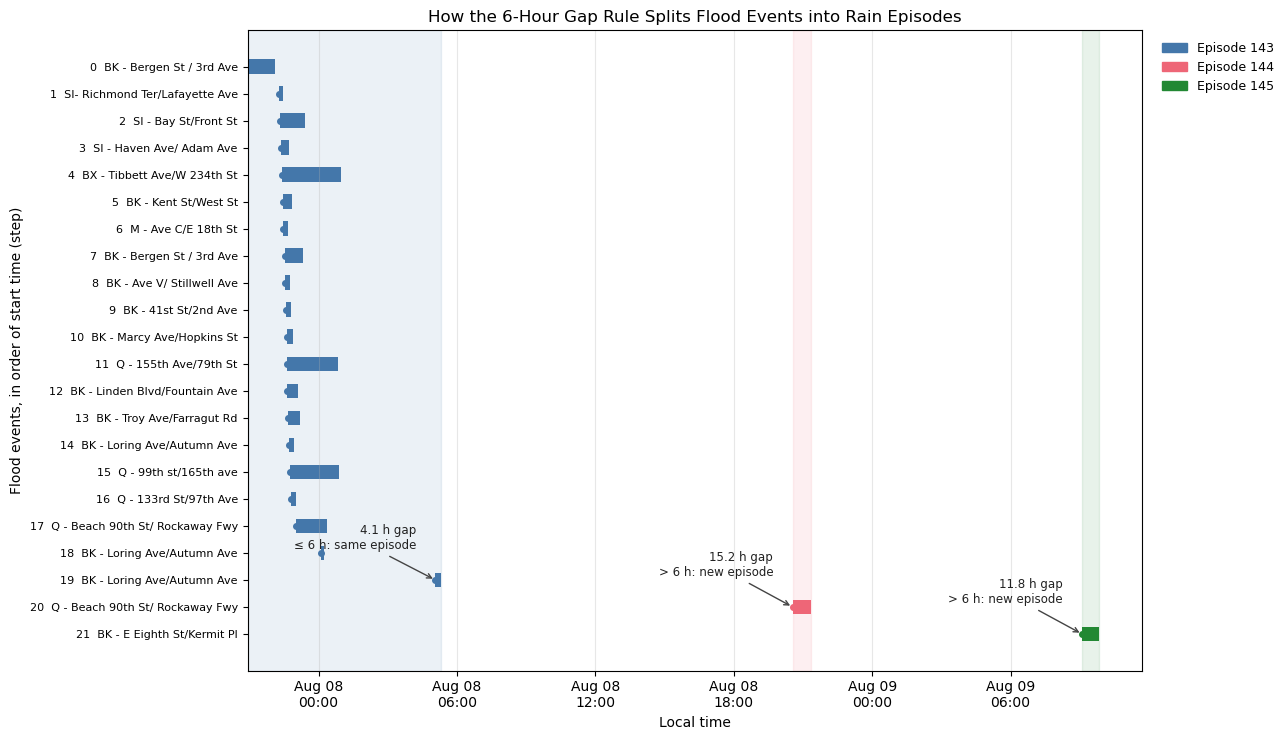

In [5]:
import matplotlib.dates as mdates

episode_ids = sorted(walkthrough_df["episode_id"].unique().to_list())
episode_colors = {episode_id: colors[i] for i, episode_id in enumerate(episode_ids)}
events = walkthrough_df.to_dicts()

fig, ax = plt.subplots(figsize=(13, 7.5))

# a light band behind each episode's full span
for episode_id in episode_ids:
    in_episode = [e for e in events if e["episode_id"] == episode_id]
    ax.axvspan(
        min(e["flood_start_time_et"] for e in in_episode),
        max(e["flood_end_time_et"] for e in in_episode),
        color=episode_colors[episode_id], alpha=0.10,
    )

# one bar per flood event, in the order the rule walks them
for y, event in enumerate(events):
    start, end = event["flood_start_time_et"], event["flood_end_time_et"]
    color = episode_colors[event["episode_id"]]
    ax.barh(y, mdates.date2num(end) - mdates.date2num(start),
            left=mdates.date2num(start), height=0.55, color=color)
    # many events are only minutes long, so mark the start too
    ax.plot(mdates.date2num(start), y, "o", markersize=4, color=color)

# call out the three gaps that decide where episodes break
for y, label in [
    (19, "4.1 h gap\n≤ 6 h: same episode"),
    (20, "15.2 h gap\n> 6 h: new episode"),
    (21, "11.8 h gap\n> 6 h: new episode"),
]:
    ax.annotate(
        label,
        xy=(mdates.date2num(events[y]["flood_start_time_et"]), y),
        xytext=(-14, 30), textcoords="offset points",
        ha="right", va="center", fontsize=8.5, color="#222222",
        arrowprops=dict(arrowstyle="->", color="#444444", linewidth=1),
    )

ax.set_yticks(range(len(events)))
ax.set_yticklabels([f'{e["step"]}  {e["sensor_name"]}' for e in events], fontsize=8)
ax.invert_yaxis()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
ax.set_xlabel("Local time")
ax.set_ylabel("Flood events, in order of start time (step)")
ax.set_title("How the 6-Hour Gap Rule Splits Flood Events into Rain Episodes")
ax.legend(
    [plt.Rectangle((0, 0), 1, 1, color=episode_colors[e]) for e in episode_ids],
    [f"Episode {e}" for e in episode_ids],
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9,
)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Each bar is one flood event, each color is one episode, and the shaded band behind them is that episode's full span. The block on the evening of August 7 is sixteen different sensors flooding within half an hour of each other. Counting those as sixteen floods would be counting one storm sixteen times, which is what the grouping prevents.

# 3) Why `cum_max` and Not the Previous Row
The rule compares each event to `latest_end_so_far`, the running maximum of all earlier end times, rather than to the row directly above it. That distinction matters because events overlap. A long flood at one sensor can still be underway while several shorter floods start and finish, and sorting by start time then places a *short* event immediately before an event that the *long* one should have absorbed.

In [6]:
naive_df = (
    rain_events_df
    .sort("flood_start_time_et")
    .with_columns(
        # what a naive rule would use: the end time of the previous row only
        pl.col("flood_end_time_et").shift(1).alias("previous_end"),
    )
    .with_columns(
        ((pl.col("flood_start_time_et") - pl.col("previous_end"))
         .dt.total_seconds() / 3600).round(2).alias("gap_to_previous_row"),
        ((pl.col("flood_start_time_et") - pl.col("latest_end_so_far"))
         .dt.total_seconds() / 3600).round(2).alias("gap_to_latest_end"),
    )
    .with_columns(
        (pl.col("gap_to_previous_row") > EPISODE_GAP_HOURS).fill_null(True).alias("naive_split"),
        (pl.col("gap_to_latest_end") > EPISODE_GAP_HOURS).fill_null(True).alias("cum_max_split"),
    )
)

print(f"Episodes using the previous row only: {naive_df['naive_split'].sum()}")
print(f"Episodes using cum_max:               {naive_df['cum_max_split'].sum()}")

naive_df.filter(pl.col("naive_split") != pl.col("cum_max_split")).select(
    "sensor_name", "flood_start_time_et",
    "gap_to_previous_row", "gap_to_latest_end", "naive_split", "cum_max_split",
)

Episodes using the previous row only: 160
Episodes using cum_max:               157


sensor_name,flood_start_time_et,gap_to_previous_row,gap_to_latest_end,naive_split,cum_max_split
str,"datetime[μs, America/New_York]",f64,f64,bool,bool
"""BX - Tibbett Ave/W 234th St""",2026-03-16 17:08:48 EDT,9.1,-0.1,true,false
"""Q - 155th Ave/79th St""",2026-05-24 18:09:33 EDT,6.04,0.42,true,false
"""Q - 188th St/ 58th Ave""",2026-07-31 04:49:44 EDT,7.07,-16.5,true,false


Only three events are affected, but each is a real error avoided. Take the July 2026 case: the row above it ended 7.1 hours earlier, so a previous-row rule would declare a new storm, while flooding elsewhere in the network was still ongoing and would not end for another 16 hours. `cum_max` keeps the network's flooding as one continuous stretch, which is what an episode is meant to be.

# 4) How Much Does the 6-Hour Choice Matter?
Two views of the threshold. On the left, the distribution of the gaps the rule tests. On the right, how many episodes we would get from every threshold between 1 and 48 hours.

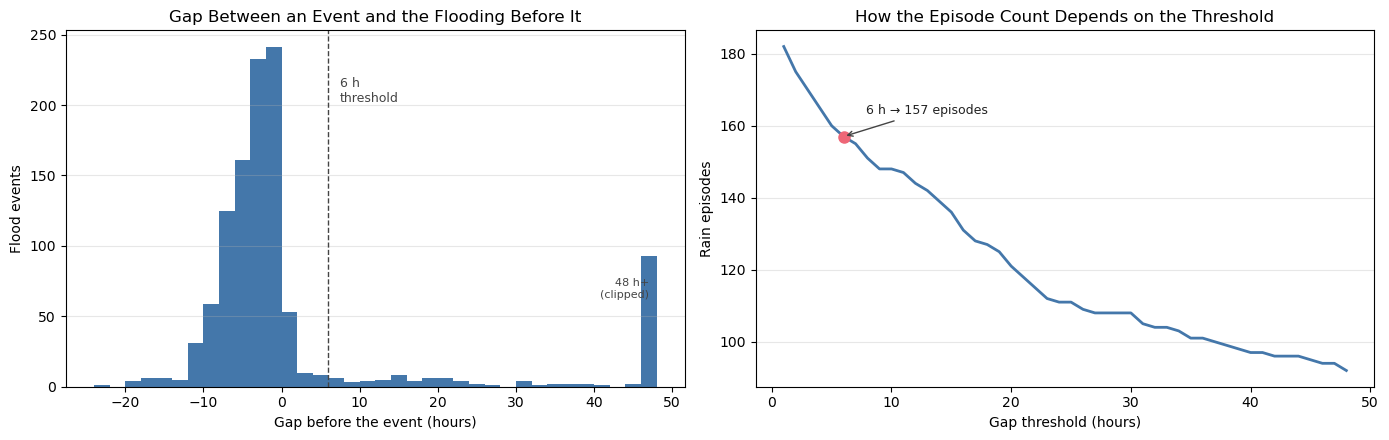

79% of events begin while flooding is already underway somewhere else in the network


In [7]:
gap_hours = (
    rain_events_df
    .with_columns(
        ((pl.col("flood_start_time_et") - pl.col("latest_end_so_far"))
         .dt.total_seconds() / 3600).alias("gap_hours")
    )
    .drop_nulls("gap_hours")["gap_hours"]
    .to_numpy()
)


def count_episodes(gap_threshold_hours):
    """Number of episodes the rule would produce at a given gap threshold."""
    return int((gap_hours > gap_threshold_hours).sum()) + 1


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# left: the quantity the rule thresholds, with the long tails clipped in
CLIP_LOW, CLIP_HIGH = -24, 48
axes[0].hist(np.clip(gap_hours, CLIP_LOW, CLIP_HIGH),
             bins=np.arange(CLIP_LOW, CLIP_HIGH + 2, 2), color=NON_TIDAL_COLOR)
axes[0].axvline(EPISODE_GAP_HOURS, color="#444444", linestyle="--", linewidth=1)
axes[0].text(EPISODE_GAP_HOURS + 1.5, axes[0].get_ylim()[1] * 0.8,
             f"{EPISODE_GAP_HOURS} h\nthreshold", color="#444444", fontsize=9)
axes[0].text(CLIP_HIGH - 1, axes[0].get_ylim()[1] * 0.25, "48 h+\n(clipped)",
             color="#444444", fontsize=8, ha="right")
axes[0].set_xlabel("Gap before the event (hours)")
axes[0].set_ylabel("Flood events")
axes[0].set_title("Gap Between an Event and the Flooding Before It")
axes[0].grid(axis="y", alpha=0.3)

# right: how sensitive the episode count is to the threshold we picked
thresholds = np.arange(1, 49)
axes[1].plot(thresholds, [count_episodes(t) for t in thresholds],
             color=NON_TIDAL_COLOR, linewidth=2)
axes[1].plot(EPISODE_GAP_HOURS, count_episodes(EPISODE_GAP_HOURS),
             "o", markersize=8, color=colors[1])
axes[1].annotate(f"{EPISODE_GAP_HOURS} h → {count_episodes(EPISODE_GAP_HOURS)} episodes",
                 xy=(EPISODE_GAP_HOURS, count_episodes(EPISODE_GAP_HOURS)),
                 xytext=(16, 16), textcoords="offset points", fontsize=9, color="#222222",
                 arrowprops=dict(arrowstyle="->", color="#444444", linewidth=1))
axes[1].set_xlabel("Gap threshold (hours)")
axes[1].set_ylabel("Rain episodes")
axes[1].set_title("How the Episode Count Depends on the Threshold")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{(gap_hours <= 0).mean() * 100:.0f}% of events begin while flooding "
      "is already underway somewhere else in the network")

The gap distribution is strongly one-sided. About 79% of events start while flooding is already underway somewhere, so they join the current episode no matter which threshold we pick; those are the negative gaps in the spike left of zero. Only the thin tail to the right of the spike is actually in play, which is why the threshold has less leverage than it might seem.

The sensitivity curve on the right deserves an honest reading: there is no flat plateau and no natural "correct" number of episodes. The count falls smoothly, from 182 episodes at 1 hour to 92 at 48 hours. Our 6-hour choice is defensible by hydrological convention, not because the data marks a break there.

**What not to do:** report the episode count as a fact about NYC flooding. It is a fact about the record *and* our threshold. What we can check is whether the results we actually care about move when the threshold does.

In [8]:
def rank_top_storms(gap_threshold_hours, top_n=5):
    """Rebuild episodes at a different gap threshold and return the biggest storms.

    Same rule as section 1, with the threshold left open.
    """
    episodes = (
        rain_events_df
        .sort("flood_start_time_et")
        .with_columns(pl.col("flood_end_time_et").cum_max().shift(1).alias("latest_end"))
        .with_columns(
            ((pl.col("flood_start_time_et") - pl.col("latest_end"))
             > pl.duration(hours=gap_threshold_hours))
            .fill_null(True).cum_sum().alias("episode_id")
        )
        # one row per sensor per episode, deepest reading
        .group_by("episode_id", "sensor_id")
        .agg(
            pl.col("flood_start_time_et").min().alias("start_time"),
            pl.col("max_depth_inches").max().alias("max_depth_inches"),
        )
        .group_by("episode_id")
        .agg(
            pl.col("start_time").min().dt.date().alias("start_date"),
            (pl.col("max_depth_inches") >= DEPTH_THRESHOLD_IN).sum().alias("sensors_4in"),
        )
    )
    return (
        episodes
        .sort("sensors_4in", descending=True)
        .head(top_n)
        .select(
            pl.col("start_date").alias(f"date_{gap_threshold_hours}h"),
            pl.col("sensors_4in").alias(f"sensors_{gap_threshold_hours}h"),
        )
        .with_row_index("rank", offset=1)
    )


comparison_df = rank_top_storms(3)
for threshold in [6, 12, 24]:
    comparison_df = comparison_df.join(rank_top_storms(threshold), on="rank")

print("Biggest storms under four different gap thresholds:\n")
comparison_df

Biggest storms under four different gap thresholds:



rank,date_3h,sensors_3h,date_6h,sensors_6h,date_12h,sensors_12h,date_24h,sensors_24h
u32,date,u32,date,u32,date,u32,date,u32
1,2025-10-30,61,2025-10-30,61,2025-10-30,61,2025-10-30,61
2,2026-05-20,44,2026-05-20,44,2026-05-20,44,2026-05-20,44
3,2026-08-20,43,2026-08-20,43,2026-08-20,43,2026-08-20,43
4,2026-07-18,40,2026-07-18,40,2026-07-18,40,2026-07-18,40
5,2026-08-23,35,2026-08-23,35,2026-08-23,35,2026-08-23,35


The five biggest storms are the same five, in the same order, with the same counts, whether we separate storms by 3 hours or by 24. Big storms are sharply enough bounded in time that no reasonable threshold splits or merges them. So conclusions about *which* storms were worst are robust to this choice, even though the total number of episodes is not.

# 5) What the Grouping Produced
With the rule checked, here is the shape of what came out of it.

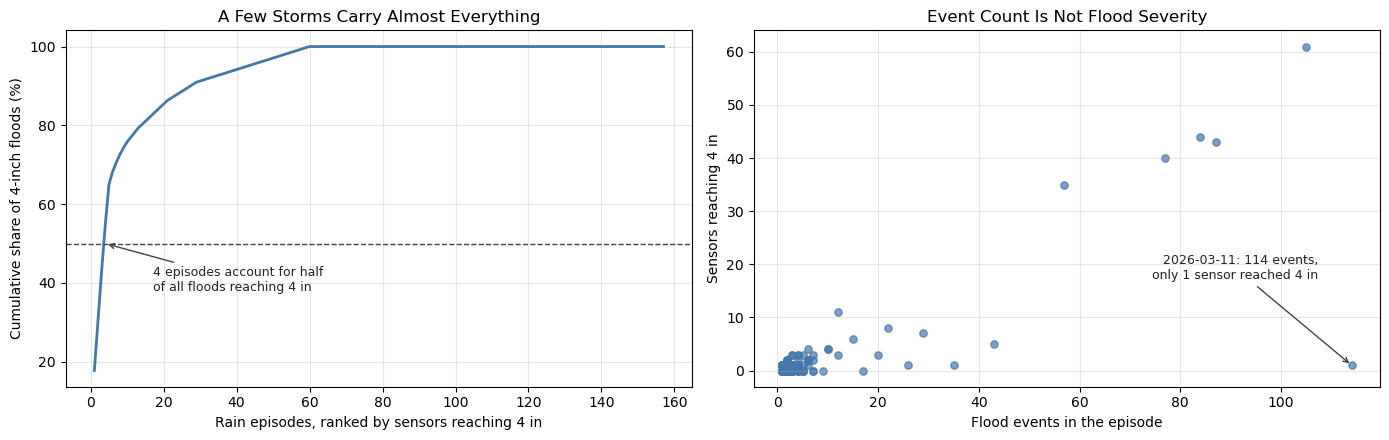

Episodes where no sensor reached 4 in: 97 of 157


In [9]:
ranked_by_size = episodes_df.sort("sensors_4in", descending=True)["sensors_4in"].to_numpy()
cumulative_share = np.cumsum(ranked_by_size) / ranked_by_size.sum() * 100

episode_sizes_df = (
    rain_events_df
    .group_by("episode_id").agg(pl.len().alias("events"))
    .join(episodes_df.select("episode_id", "sensors_4in", "start_date"), on="episode_id")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(np.arange(1, len(ranked_by_size) + 1), cumulative_share,
             color=NON_TIDAL_COLOR, linewidth=2)
axes[0].axhline(50, color="#444444", linestyle="--", linewidth=1)
episodes_for_half = int(np.searchsorted(cumulative_share, 50) + 1)
axes[0].annotate(f"{episodes_for_half} episodes account for half\nof all floods reaching 4 in",
                 xy=(episodes_for_half, 50), xytext=(34, -34), textcoords="offset points",
                 fontsize=9, color="#222222",
                 arrowprops=dict(arrowstyle="->", color="#444444", linewidth=1))
axes[0].set_xlabel("Rain episodes, ranked by sensors reaching 4 in")
axes[0].set_ylabel("Cumulative share of 4-inch floods (%)")
axes[0].set_title("A Few Storms Carry Almost Everything")
axes[0].grid(alpha=0.3)

axes[1].scatter(episode_sizes_df["events"], episode_sizes_df["sensors_4in"],
                s=28, color=NON_TIDAL_COLOR, alpha=0.7)
busiest = episode_sizes_df.sort("events", descending=True).head(1).to_dicts()[0]
axes[1].annotate(f"{busiest['start_date']}: {busiest['events']} events,\n"
                 f"only {busiest['sensors_4in']} sensor reached 4 in",
                 xy=(busiest["events"], busiest["sensors_4in"]),
                 xytext=(-24, 62), textcoords="offset points", ha="right",
                 fontsize=9, color="#222222",
                 arrowprops=dict(arrowstyle="->", color="#444444", linewidth=1))
axes[1].set_xlabel("Flood events in the episode")
axes[1].set_ylabel("Sensors reaching 4 in")
axes[1].set_title("Event Count Is Not Flood Severity")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

quiet_episodes = episodes_df.filter(pl.col("sensors_4in") == 0).height
print(f"Episodes where no sensor reached 4 in: {quiet_episodes} of {episodes_df.height}")

Two things to take from this:

- **Flooding is extremely concentrated.** Four episodes account for half of every sensor-episode that reached 4 inches, and 97 of the 157 episodes had no sensor reach 4 inches at all. The flat right-hand stretch of the left chart is those quiet episodes contributing nothing.
- **Event count is not severity.** The episode beginning March 11, 2026 has the most events in the record, 114 of them across 76 sensors, yet only one sensor reached 4 inches; every other sensor stayed below 1.5 inches. It was light rain touching much of the city at once. An analysis that ranked storms by event count would put it first.

This is also why the depth threshold and the episode grouping are separate decisions. Grouping fixes double-counting; the depth threshold decides what counts as flooding at all.

# 6) Every Episode in the Record
One row per year, one marker per rain episode.

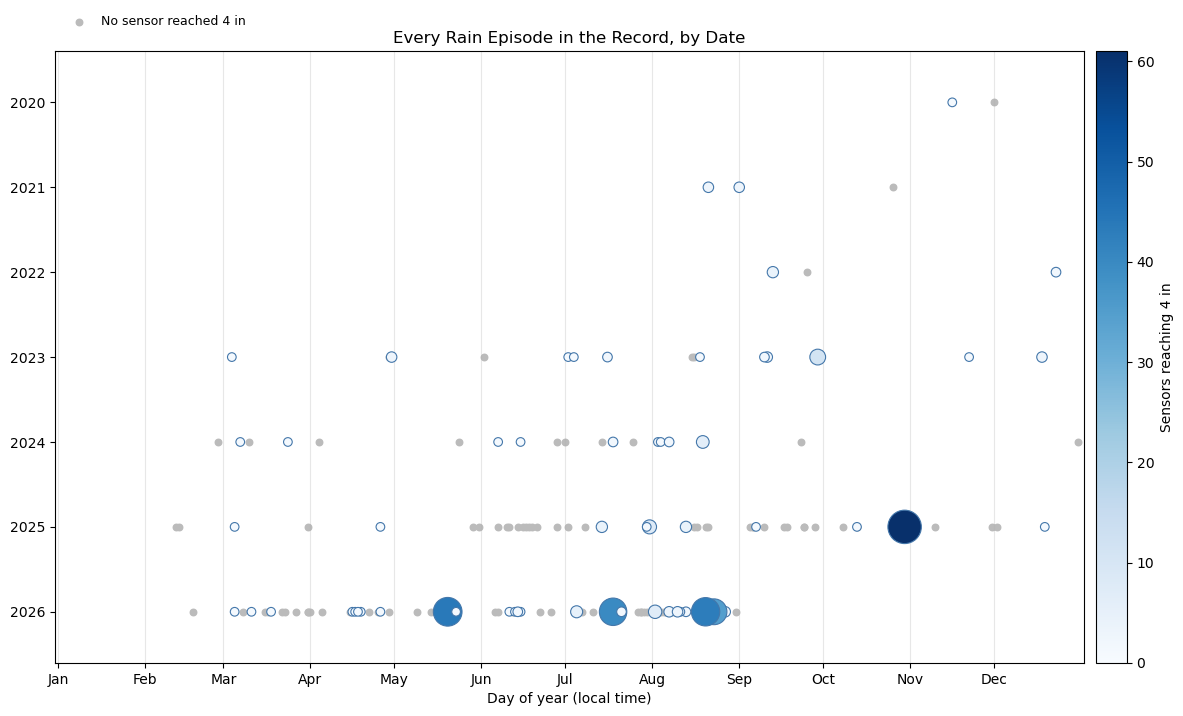

In [10]:
calendar_df = episodes_df.with_columns(
    pl.col("episode_start").dt.year().alias("year"),
    pl.col("episode_start").dt.ordinal_day().alias("day_of_year"),
)
years = sorted(calendar_df["year"].unique().to_list())

fig, ax = plt.subplots(figsize=(13, 0.75 * len(years) + 2))

quiet_df = calendar_df.filter(pl.col("sensors_4in") == 0)
ax.scatter(quiet_df["day_of_year"], quiet_df["year"], s=22, color=colors[6],
           label="No sensor reached 4 in")

flooded_df = calendar_df.filter(pl.col("sensors_4in") > 0)
points = ax.scatter(
    flooded_df["day_of_year"], flooded_df["year"],
    s=30 + flooded_df["sensors_4in"] * 9,
    c=flooded_df["sensors_4in"], cmap="Blues",
    vmin=0, vmax=flooded_df["sensors_4in"].max(),
    # an outline keeps the palest (smallest) storms visible
    edgecolors=NON_TIDAL_COLOR, linewidths=0.8, zorder=3,
)

# first day-of-year of each month in a non-leap year
ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335],
              ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_yticks(years)
ax.set_ylim(max(years) + 0.6, min(years) - 0.6)
ax.set_xlim(0, 367)
ax.set_xlabel("Day of year (local time)")
ax.set_title("Every Rain Episode in the Record, by Date")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), frameon=False, fontsize=9)
fig.colorbar(points, ax=ax, label="Sensors reaching 4 in", pad=0.01)

plt.tight_layout()
plt.show()

This is the entire dataset behind the rest of the notebook, and several things are visible at once:

- **The record is short and lopsided.** 2020 through 2022 hold a handful of episodes; most of the record is 2025 and 2026. That is the network growing, which [05-temporal-patterns.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/05-temporal-patterns.ipynb) covers, not the weather changing.
- **The big storms are isolated.** The dark markers, including October 30, 2025, are a small number of separate days rather than clusters.
- **Most markers are gray.** Most rain episodes never put four inches of water on any street.

Read this chart as an inventory, not as seasonality. Comparing rows means comparing years with very different numbers of sensors watching, which is the problem [05-temporal-patterns.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/05-temporal-patterns.ipynb) handles properly in its seasonality section.

# 7) Episodes Versus Calendar Days
A simpler alternative to the 6-hour rule is to group events by calendar date. It gives a similar count here, which is worth understanding rather than taking as agreement.

In [11]:
flood_days = rain_events_df["flood_date"].n_unique()
episodes_crossing_midnight = episodes_df.filter(pl.col("start_date") != pl.col("end_date")).height
days_with_several = (
    episodes_df.group_by("start_date").agg(pl.len().alias("episodes"))
    .filter(pl.col("episodes") > 1).height
)

print(f"Calendar days with a non-tidal flood event: {flood_days}")
print(f"Rain episodes:                              {episodes_df.height}")
print(f"Episodes that cross midnight:               {episodes_crossing_midnight}")
print(f"Days hosting more than one episode:         {days_with_several}")

episodes_df.filter(pl.col("start_date") != pl.col("end_date")).select(
    "start_date", "end_date", "episode_start", "episode_end", "duration_hours", "sensors_4in"
).sort("duration_hours", descending=True).head(5)

Calendar days with a non-tidal flood event: 161
Rain episodes:                              157
Episodes that cross midnight:               43
Days hosting more than one episode:         9


start_date,end_date,episode_start,episode_end,duration_hours,sensors_4in
date,date,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",f64,u32
2026-03-18,2026-03-21,2026-03-18 14:36:17 EDT,2026-03-21 18:19:12 EDT,75.7,1
2026-05-23,2026-05-25,2026-05-23 14:30:09 EDT,2026-05-25 13:28:02 EDT,47.0,1
2026-07-05,2026-07-07,2026-07-05 21:18:54 EDT,2026-07-07 01:31:39 EDT,28.2,5
2026-03-05,2026-03-06,2026-03-05 07:30:25 EST,2026-03-06 11:00:01 EST,27.5,1
2026-07-30,2026-07-31,2026-07-30 18:36:41 EDT,2026-07-31 21:19:36 EDT,26.7,0


161 flood days and 157 episodes are close, but they are not the same 157 things. 43 episodes cross midnight, so a date-based grouping would split each of them into two separate "flood days", and 9 days hosted more than one episode, which a date-based grouping would merge into one. The longest episode ran 75.7 hours across four calendar dates.

Calendar-day grouping also has a flaw the gap rule does not: midnight is an arbitrary boundary for rain. A storm starting at 11 pm gets cut in half, while one starting at noon does not. Hurricane Ida is the case in point ([05-temporal-patterns.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/05-temporal-patterns.ipynb) checks the time zone conversion against it), with its flooding starting the evening before the date the storm is usually given.

**Decision:** we keep the 6-hour gap rule. It is not obviously better than the calendar at counting storms, but it is at least defined by the flooding rather than by the clock, and the checks above show that the results we care about survive the choice.